In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [6]:
digits = load_digits()


In [7]:
df = pd.DataFrame(digits.data)


In [8]:
X = digits.data
y = digits.target


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
param_grid = {
    'n_neighbors': range(1, 21)
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)})

In [11]:
print("Best K Value:", grid.best_params_)


Best K Value: {'n_neighbors': 1}


In [12]:
knn = grid.best_estimator_


In [13]:
score = knn.score(X_test, y_test)

print("Accuracy Score:", score)

Accuracy Score: 0.9777777777777777


In [14]:
y_pred = knn.predict(X_test)


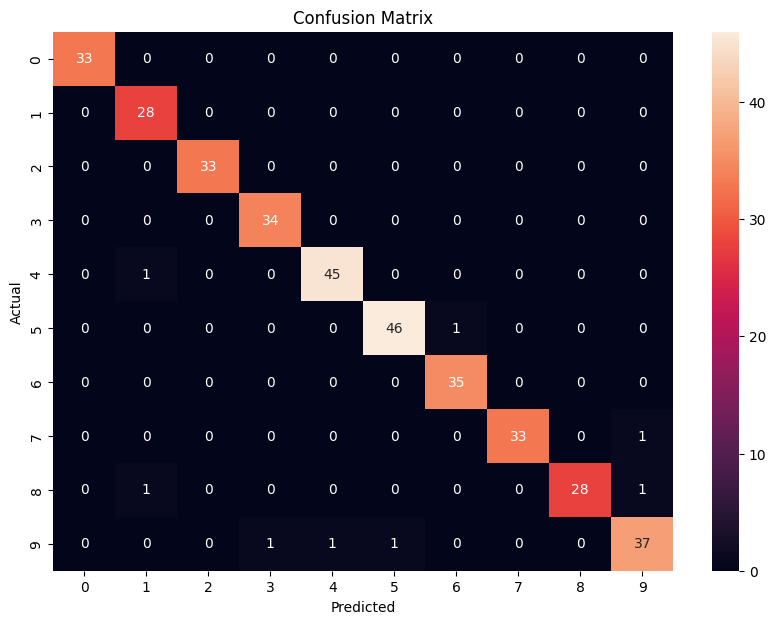

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
report = classification_report(y_test, y_pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

